# Data Scrapping

In [10]:
# !{sys.executable} -m pip install yfinance


In [11]:
'''
import yfinance as yf

# Download full historical data for Bitcoin
btc = yf.Ticker("BTC-USD")
btc_data = btc.history(period="max", interval="1d")
btc_data.to_csv("BTC-USD_full_history.csv")
print(f"Saved {len(btc_data)} rows to BTC-USD_full_history.csv")

# Download full historical data for Ethereum
eth = yf.Ticker("ETH-USD")
eth_data = eth.history(period="max", interval="1d")
eth_data.to_csv("ETH-USD_full_history.csv")
print(f"Saved {len(eth_data)} rows to ETH-USD_full_history.csv")

print("\nBoth CSV files have been saved in your working folder.")
'''

'\nimport yfinance as yf\n\n# Download full historical data for Bitcoin\nbtc = yf.Ticker("BTC-USD")\nbtc_data = btc.history(period="max", interval="1d")\nbtc_data.to_csv("BTC-USD_full_history.csv")\nprint(f"Saved {len(btc_data)} rows to BTC-USD_full_history.csv")\n\n# Download full historical data for Ethereum\neth = yf.Ticker("ETH-USD")\neth_data = eth.history(period="max", interval="1d")\neth_data.to_csv("ETH-USD_full_history.csv")\nprint(f"Saved {len(eth_data)} rows to ETH-USD_full_history.csv")\n\nprint("\nBoth CSV files have been saved in your working folder.")\n'

## Time Series v1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

btc_data = pd.read_csv("BTC-USD_full_history.csv")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [13]:
print(btc_data.shape)
btc_data.head(1)

(4037, 8)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0


<Axes: >

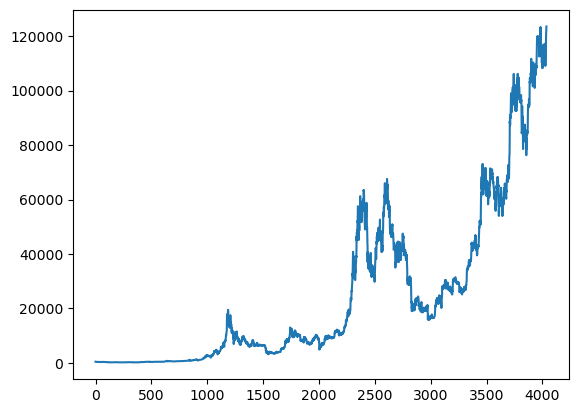

In [14]:
btc_data['Close'].plot()

In [15]:
btc_data.index

RangeIndex(start=0, stop=4037, step=1)

## Time Series v2

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Index_col chooses the column to be used as the index
# parse_dates converts the index to datetime format
btc_data = pd.read_csv("BTC-USD_full_history.csv", index_col='Date', parse_dates=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [17]:
print(btc_data.shape)
btc_data.head(1)

(4037, 7)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0


In [18]:
btc_data.dtypes

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

<Axes: xlabel='Date'>

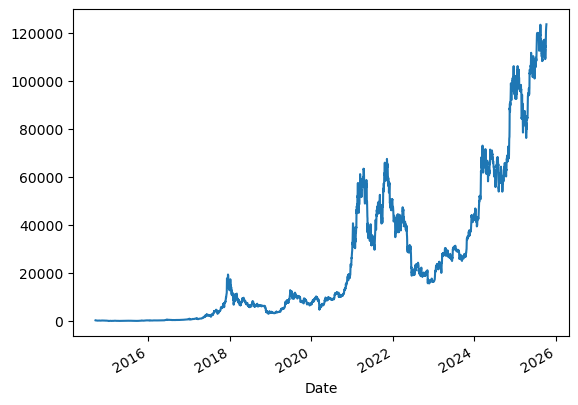

In [19]:
btc_data['Close'].plot()

In [20]:
btc_data.index

DatetimeIndex(['2014-09-17 00:00:00+00:00', '2014-09-18 00:00:00+00:00',
               '2014-09-19 00:00:00+00:00', '2014-09-20 00:00:00+00:00',
               '2014-09-21 00:00:00+00:00', '2014-09-22 00:00:00+00:00',
               '2014-09-23 00:00:00+00:00', '2014-09-24 00:00:00+00:00',
               '2014-09-25 00:00:00+00:00', '2014-09-26 00:00:00+00:00',
               ...
               '2025-09-26 00:00:00+00:00', '2025-09-27 00:00:00+00:00',
               '2025-09-28 00:00:00+00:00', '2025-09-29 00:00:00+00:00',
               '2025-09-30 00:00:00+00:00', '2025-10-01 00:00:00+00:00',
               '2025-10-02 00:00:00+00:00', '2025-10-03 00:00:00+00:00',
               '2025-10-04 00:00:00+00:00', '2025-10-06 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date', length=4037, freq=None)

<Axes: xlabel='Date'>

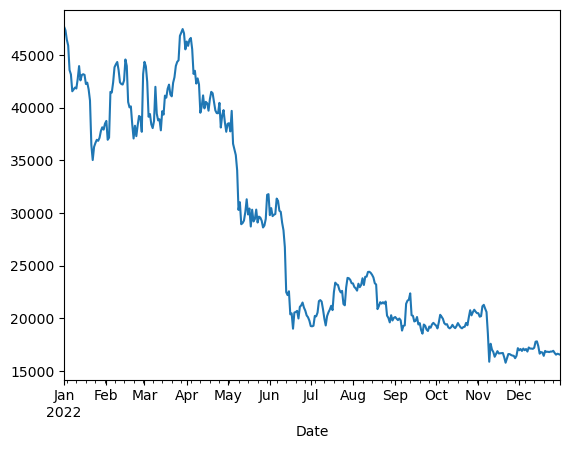

In [21]:
btc_data.loc['2022']['Close'].plot()

<Axes: xlabel='Date'>

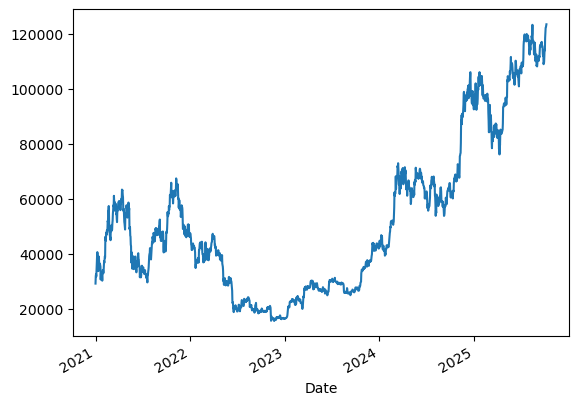

In [22]:
btc_data.loc['2021':'2025']['Close'].plot()

<Axes: xlabel='Date'>

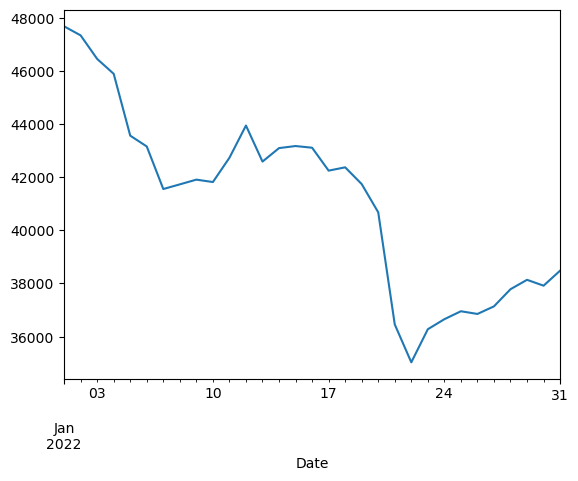

In [23]:
# Pandas adapts to different date formats such as: 
# '2022-01-01' or '2022 March' or '2022/01/01' or '2022-1-1' or '2022/1/1' or '2022-01-01 00:00:00+00:00' or '2022-1-1 0:0:0+0'
# You can go as deep as nanoseconds or as high as years
btc_data.loc['2022-01']['Close'].plot()

<Axes: xlabel='Date'>

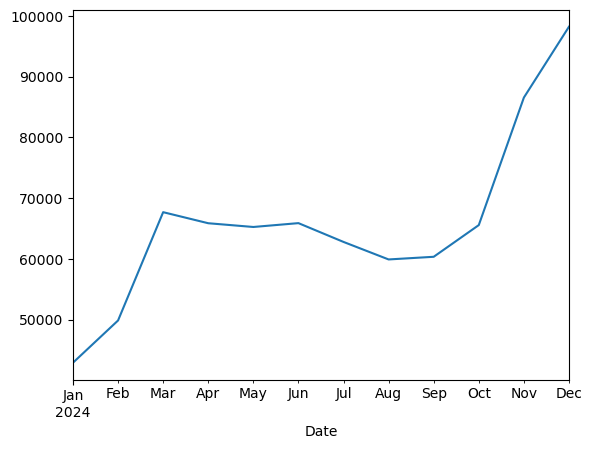

In [24]:
btc_data.loc['2024','Close'].resample('M').mean().plot()

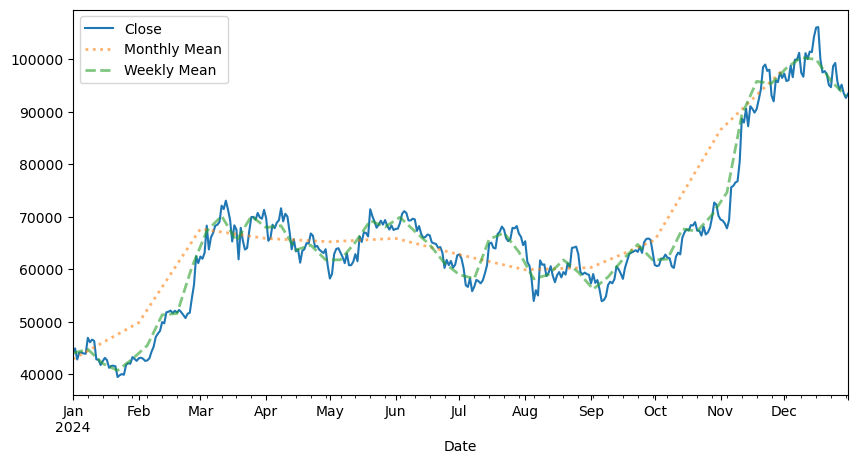

In [25]:
plt.figure(figsize=(10,5))
btc_data.loc['2024','Close'].plot()
btc_data.loc['2024','Close'].resample('M').mean().plot(label='Monthly Mean', lw=2, ls=':', alpha=0.6)
btc_data.loc['2024','Close'].resample('W').mean().plot(label='Weekly Mean', lw=2, ls='--', alpha=0.6)
plt.legend()
plt.show()

## Time Series v3

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Index_col chooses the column to be used as the index
# parse_dates converts the index to datetime format
btc_data = pd.read_csv("BTC-USD_full_history.csv", index_col='Date', parse_dates=True)
eth_data = pd.read_csv("ETH-USD_full_history.csv", index_col='Date', parse_dates=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<Axes: xlabel='Date'>

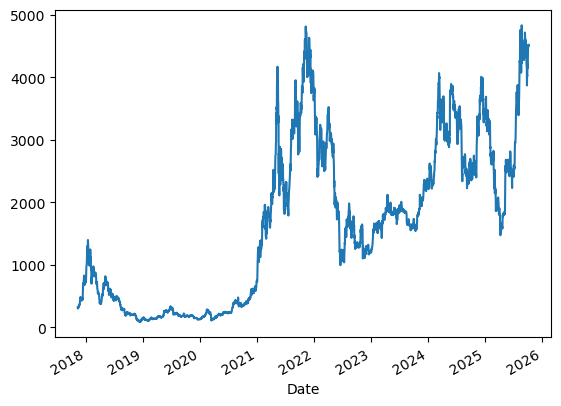

In [27]:
eth_data['Close'].plot()

In [28]:
print(eth_data.shape)
print(btc_data.shape)

(2888, 7)
(4037, 7)


In [29]:
crypto = pd.merge(btc_data, eth_data, on='Date', how='inner', suffixes=('_BTC', '_ETH'))

print(crypto.shape)
crypto.head(1)

(2888, 14)


,Open_BTC,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Dividends_BTC,Stock Splits_BTC,Open_ETH,High_ETH,Low_ETH,Close_ETH,Volume_ETH,Dividends_ETH,Stock Splits_ETH
Date,,,,,,,,,,,,,,
2017-11-09 00:00:00+00:00,7446.830078,7446.830078,7101.52002,7143.580078,3226249984,0.0,0.0,308.644989,329.451996,307.056,320.884003,893249984,0.0,0.0


<Axes: xlabel='Date'>

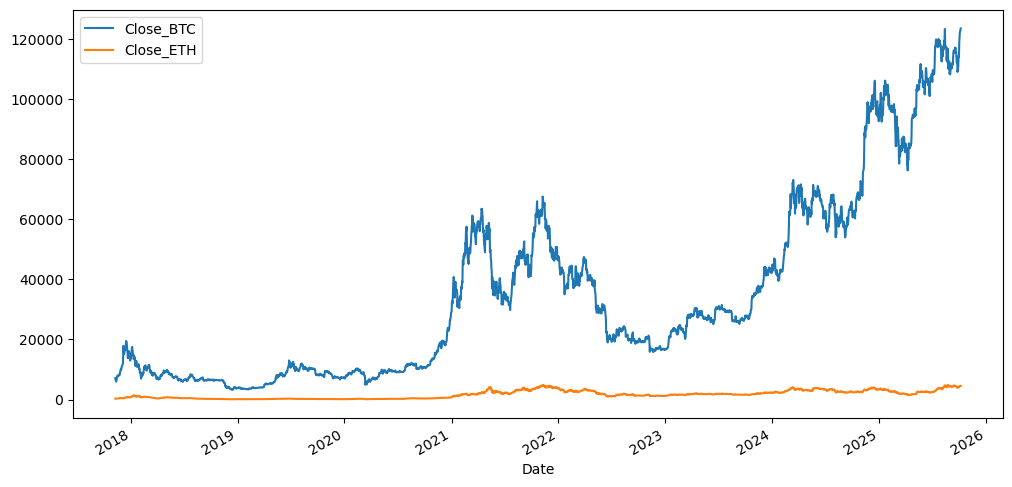

In [30]:
crypto[['Close_BTC','Close_ETH']].plot(figsize=(12,6))

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

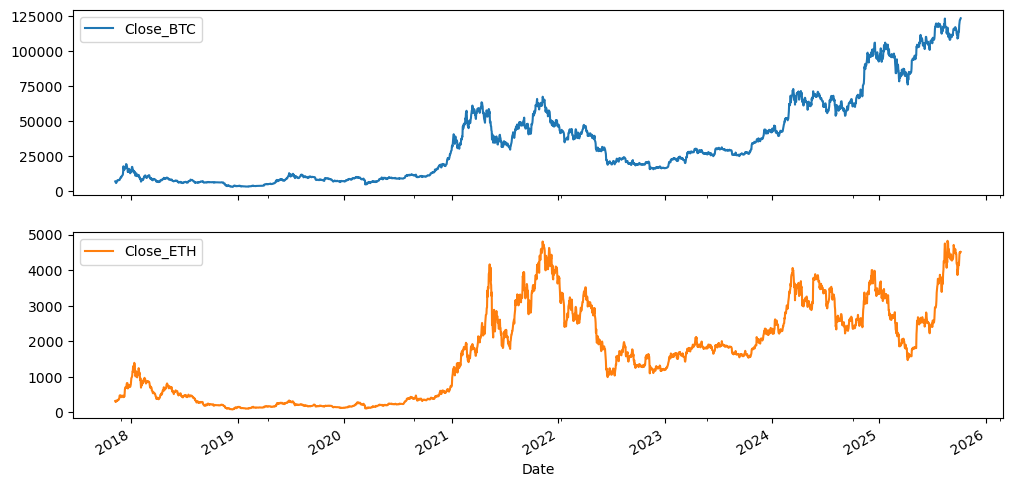

In [32]:
crypto[['Close_BTC','Close_ETH']].plot(subplots=True,figsize=(12,6))

In [34]:
corelation = crypto[['Close_BTC','Close_ETH']].corr()
corelation

,Close_BTC,Close_ETH
Close_BTC,1.000000,0.831431
Close_ETH,0.831431,1.000000


<Axes: >

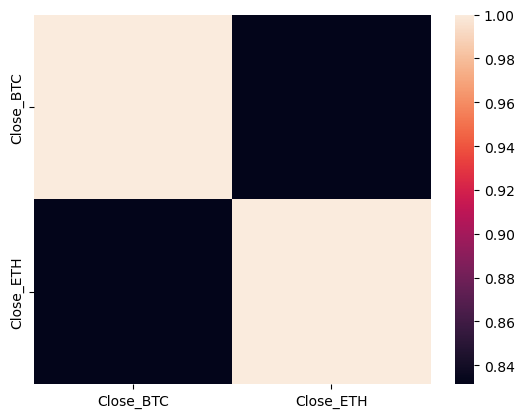

In [36]:
import seaborn as sns
sns.heatmap(corelation)